<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic2.1-Non-parametric_Models/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Non-parametric Models

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic2.1-Non-parametric_Models_Problems.zip) <archives/Topic2.1-Non-parametric_Models_Problems.zip>` — the notebook and
`r32_propane_vle.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Non-parametric Models </2-regression/Topic2.1-Non-parametric_Models>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::



## Setup

A **refrigerant blend** is a mixture of two or more working fluids chosen to hit a
pressure and temperature that neither component reaches on its own. Blends have one
awkward property: when a charge leaks, the vapor that escapes is richer in the more
volatile component, so the composition left in the system drifts and its performance
drifts with it. Unless the blend is **azeotropic** — at the azeotrope the vapor and
liquid have the *same* composition, nothing fractionates, and a leaking system can simply
be topped up.

So for a blend, one number matters more than any other: the composition at which

$$
y_1 = x_1 ,
$$

where $x_1$ is the mole fraction of a component in the liquid and $y_1$ its mole fraction
in the vapor it is in equilibrium with. Finding it is a job for interpolation. Nobody
measures *at* the azeotrope, because you do not know where it is until you have measured
around it.

This set uses vapor-liquid equilibrium measurements for **difluoromethane (R32) +
propane**, an azeotropic pair, from Coquelet et al., *J. Chem. Eng. Data* **48**, 317
(2003), [doi:10.1021/je020115d](https://doi.org/10.1021/je020115d), retrieved from the
NIST ThermoML Archive. Each row is one equilibrium measurement: a temperature, the
pressure, the liquid composition, and the vapor composition.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/r32_propane_vle.csv')
temperatures = sorted(df['temperature [K]'].unique())
print(f"{len(df)} measurements across {len(temperatures)} isotherms: {temperatures}")

# Parts A and B work on one isotherm: 294.83 K.
iso = df[df['temperature [K]'] == 294.83]
x_liq = iso['x_R32'].values
y_vap = iso['y_R32'].values
p_iso = iso['pressure [MPa]'].values
print(f"294.83 K: {len(x_liq)} points, x_R32 from {x_liq.min()} to {x_liq.max()}")

79 measurements across 5 isotherms: [np.float64(278.1), np.float64(294.83), np.float64(303.23), np.float64(313.26), np.float64(343.26)]
294.83 K: 16 points, x_R32 from 0.0 to 1.0


:::{note}
Compositions are mole fractions of **R32**, named `x_R32` and `y_R32` rather than `x1` and
`y1`. The paper's tables number R32 as component 1 and the NIST record numbers it as
component 2, so the column name spells out which component is meant and you never have to
guess.
:::

Every isotherm runs from pure propane to pure R32. Both endpoints are pure components,
where $y = x$ exactly and trivially — worth remembering later.

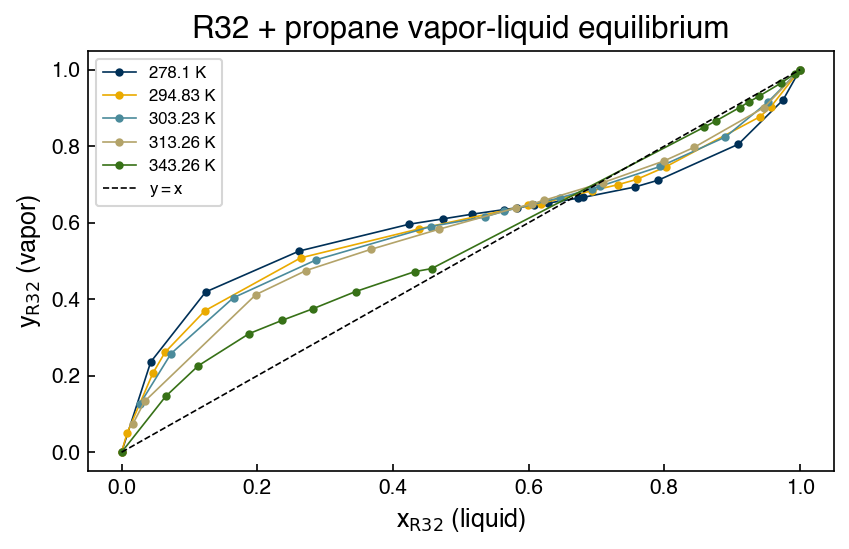

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
for T in temperatures:
    sub = df[df['temperature [K]'] == T]
    ax.plot(sub['x_R32'], sub['y_R32'], 'o-', ms=3, lw=0.8, label=f'{T} K')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='$y = x$')
ax.set_xlabel('$x_{\\mathrm{R32}}$ (liquid)')
ax.set_ylabel('$y_{\\mathrm{R32}}$ (vapor)')
ax.set_title('R32 + propane vapor-liquid equilibrium')
ax.legend(fontsize=8);

Where a curve crosses the dashed line, the vapor and the liquid have the same composition.
That crossing is the azeotrope, and locating it precisely is what the rest of this set is
about.

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (7, ['bb9342764bdf', 'bea70f72b935', 'ec31b08195fc', '7b9b3c5f3a9b', 'ce2b9e208124', 'c31e01e874f2', '893d03fec242', 'e1e0dc9abc96', 'e1e0dc9abc96', '197f3102c9d2', '197f3102c9d2', 'e4f1cda190fb', 'e4f1cda190fb', '7e3c910e8d63', '7e3c910e8d63']),
    'q2': (6, ['98c4b36d7031', '9d8eb8427f1f', 'cca6b6eeb75c', '239778d8a4fc', 'c3f810582dfe', '7fe6a1d3abf9', 'e0a151545283', '1d30eabb09fb', '0b17efa442ae', 'a6df06296caa', '90ebd94c8ca1']),
    'q3': (5, ['35883b904c9c', '33f74ad61065', '8a001a88b75b', '7e4c47919e48', 'd67623fd1254', '520678fa90fd', '79b5fd85948d', 'ee1962aa23c7', '3fd819b1a30c', 'e6546605b6b4', '3f4be80b8046', 'd6d5e4d8bb0d', '30665e5c4697', '0d646490e891', '43829aa0fedc']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

All three work on the **294.83 K isotherm only**, using the arrays `x_liq` and `y_vap`
defined above. A1 and A2 build the two design matrices from the chapter; A3 puts one of
them to work. The functions you write in A1 and A2 are used again in Parts B and C, so
write them to be reusable.

### A1. Build the hinge basis and predict between two measurements (10 pts)

:::{exercise}
:label: pr-reg-hinge-interp

The chapter frames linear interpolation as ordinary linear regression with a **hinge**
design matrix,

$$
X_{ij} = \max(0,\; x_i - x_j),
$$

one column per training point, with the last column replaced by a column of ones so that
it acts as an intercept.

Write a function

```
hinge_features(x_train, x_test=None)
```

that returns this matrix, and — this is the part that matters — returns it with **one row
per evaluation point and one column per training point**. When `x_test` is `None` it should
fall back to `x_train`, giving the square matrix you fit with. Remember to add the intercept
column.

Fit `LinearRegression(fit_intercept=False)` to all 16 points of the 294.83 K isotherm,
predicting `y_vap` from `x_liq`. Then use it to predict the vapor composition at a liquid
composition of $x_{\mathrm{R32}} = 0.55$, which is not one of the measured points.

Assign that prediction to `y_hinge`.
:::

In [ ]:
# YOUR CODE HERE
y_hinge = ...

In [ ]:
check("q1", y_hinge)

### A2. Swap in a Gaussian kernel (10 pts)

:::{exercise}
:label: pr-reg-rbf-width

Now change the basis and nothing else. A radial basis function places a smooth bump at
every training point,

$$
X_{ij} = \exp\!\left(-\gamma \,(x_i - x_j)^2\right),
\qquad
\gamma = \frac{1}{2\sigma^2},
$$

where $\sigma$ is the width of each bump, measured in the same units as $x$ — here, mole
fraction.

Write a function

```
rbf_features(x_train, x_test=None, gamma=1.0)
```

with the same row-and-column convention as `hinge_features`. This basis needs no intercept
column.

Using $\sigma = 0.05$, fit `LinearRegression(fit_intercept=False)` to the same 16 points and
predict the vapor composition at the same $x_{\mathrm{R32}} = 0.55$.

Assign the prediction to `y_rbf`.
:::

In [ ]:
# YOUR CODE HERE
y_rbf = ...

In [ ]:
check("q2", y_rbf)

### A3. Locate the azeotrope (10 pts)

:::{exercise}
:label: pr-reg-azeotrope

The azeotrope is the composition where the interpolated vapor composition equals the liquid
composition. Using the **hinge** model from A1, find it by minimizing

$$
\left[\hat{y}(x) - x\right]^2
$$

with `scipy.optimize.minimize`, starting from $x_{\mathrm{R32}} = 0.6$.

Assign the composition to `x_azeotrope`.

*The starting point is not arbitrary. Both pure components satisfy $y = x$ exactly, so
$x = 0$ and $x = 1$ are also solutions of this equation, and an optimizer started too near
either end will find one of them and report it with complete confidence.*

*`minimize` stops on its default tolerances, which here leaves the answer correct to about
five digits. That is inside the checker's tolerance, so the default is fine; tightening it
(for Nelder-Mead, `options={'xatol': 1e-12, 'fatol': 1e-18}`) gets you the exact root and
costs nothing.*
:::

In [ ]:
# YOUR CODE HERE
x_azeotrope = ...

In [ ]:
check("q3", x_azeotrope)

---

## Part B — Visualization (35 pts)

Part A gave you two design matrices and two very different answers at the same
composition. This part is about seeing why. Everything here uses the 294.83 K isotherm and
the two functions you wrote, `hinge_features` and `rbf_features`.

Evaluate every model on a fine grid so you are looking at the model, not at the points:

```
grid = np.linspace(0.0, 1.0, 300)
```

::::{exercise}
:label: pr-reg-basis-compare

**1. Two bases, all the data.** Fit the hinge model and an RBF model with $\sigma = 0.05$ to
**all 16** points, exactly as in A1 and A2. Plot both curves over `grid`, with the measured
points, on a $y_{\mathrm{R32}}$ against $x_{\mathrm{R32}}$ diagram. Report the $r^2$ of each
model on those same 16 points.

Then, in **one sentence**: the two curves pass through every measured point and have the
same $r^2$, yet at $x = 0.55$ they differ by nearly 0.2 in mole fraction. Say what that
tells you about what $r^2$ can and cannot measure here.

**2. Two bases, half the data.** Refit both models on **every other point**,

```
x_train = x_liq[::2]
y_train = y_vap[::2]
```

which leaves 8 training points. Plot both curves again, marking the training points and the
8 held-out points differently. Now score each model with `.score()` against the **full**
16-point isotherm, by evaluating its design matrix at `x_liq`.

Report both $r^2$ values and say in **one sentence** what changed from task 1 that let
$r^2$ tell the two models apart.

**3. What the kernel width does.** Keeping the same 8 training points, fit RBF models at
$\sigma = 0.02,\ 0.05,\ 0.1,\ 0.2$ and $0.3$. Plot all five curves on one set of axes with
the training points, and report a small table of $\sigma$, the $r^2$ against the full
isotherm, and `np.linalg.cond` of each training design matrix.

Then, in **two sentences**: say which end of the $\sigma$ range is dangerous here and what
goes wrong to the curve between the training points there, and say what eventually limits how
wide a kernel you can use.
::::

In [ ]:
# YOUR CODE HERE
grid = np.linspace(0.0, 1.0, 300)
fig, ax = plt.subplots()

---

## Part C — Open Ended (35 pts)

At 294.83 K the answer has been stable: the interpolant put the azeotrope in a narrow range,
and A3's teaching note told you it agrees closely with the published measurement. This part
asks whether that stability holds elsewhere in the dataset, and — the real question — how you
would know if it did not, **without a published answer to check against**. That is the
situation you are normally in.

Work with three of the five isotherms:

```
targets = [294.83, 313.26, 343.26]
```

Two things you are given rather than asked to work out.

:::{admonition} What the source says, and one number to check against
:class: note

The paper publishes an azeotropic composition at **four** of its five temperatures. For
313.26 K that value is **0.702**, which is your check that the method works. (It also
publishes one for 294.83 K; your A3 answer matches it to better than half a percent.)

At **343.26 K it publishes none.** The reason is physical and you are not asked to derive
it: near that temperature the mixture approaches its critical region, where liquid and vapor
become hard to tell apart and the experimental method cannot sample. That is why the
343.26 K measurements are distributed the way they are — and the consequences of *that*, for
interpolation, are the entire subject of this part.
:::

You also need a third basis. The chapter introduces **splines** — piecewise polynomials
joined at knots — used through a pipeline, with exactly the settings it demonstrates:

```
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

spline = make_pipeline(
    SplineTransformer(degree=3, n_knots=10, include_bias=False),
    LinearRegression(),
).fit(x.reshape(-1, 1), y)
```

A spline's flexibility is set by its **knot count** rather than by the number of training
points, so it is a genuinely different way of interpolating the same data — which is the
property this part depends on.

::::{exercise}
:label: pr-reg-method-spread

**1. One method, three isotherms.** Using the hinge basis and all of each isotherm's points,
extract the azeotropic composition at each of the three temperatures, the same way you did in
A3. Report them with the number of points in each isotherm, and compare the 313.26 K result
with the published 0.702. In **one sentence**, say how well the method does where it can be
checked.

**2. Three methods, three isotherms.** Repeat the extraction with two more bases on the same
data: RBF at $\sigma = 0.1$, and the cubic spline above. Report a table of the azeotropic
composition from each of the three methods on each of the three isotherms, together with each
model's $r^2$ on its own training points.

**3. Where the methods disagree.** Reduce your table to three numbers per isotherm: the
**spread** across the three methods (largest minus smallest), the range of their $r^2$
values, and the **largest gap between adjacent training compositions** — a property of the
inputs alone, which `np.diff` on the sorted compositions and `np.max` will give you.

Then plot the 343.26 K isotherm on its own: the measured points, the $y = x$ line, all three
interpolants over `grid`, and the interval between $x_{\mathrm{R32}} = 0.457$ and $0.858$
shaded.

In **one sentence**, say which of your two model-derived columns — the spread or the $r^2$
range — separates the isotherms from one another, and which does not.

**4. What the spread is measuring.** In **two sentences**: say what distinguishes the
343.26 K isotherm from the other two in terms of the training inputs alone, and state the
rule you would apply to decide whether to trust a non-parametric interpolant at a given
input.
::::

In [ ]:
# YOUR CODE HERE
targets = [294.83, 313.26, 343.26]